# Model 2C, Linear Discriminant Analysis Experiment 01

This append-only experiment applies Linear Discriminant Analysis (LDA) to Logistic Regression 2C-02's selected representation: BL-A-27, signed `DepDelay`, raw `TaxiOut`, actual takeoff-time cycle fields, and a fold-fitted spline of `MINUTES_TO_SCHEDULED_ARRIVAL = CRSElapsedTime - DepDelay - TaxiOut`.

The experiment compares ordinary LDA with shrinkage LDA. Solver and shrinkage are selected using five expanding 2019 folds. Imputation, category encoding, scaling, spline knots, classifier settings, and the operating threshold are learned from 2019 only. The frozen design is evaluated once on 2023. No new feature dataset is created, and 2024 is not loaded.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
N_TIME_SPLITS = 5
N_JOBS = 1
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2C experiments.


In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Hold the selected Model 2C representation fixed

All 31 saved source fields and the degree-3 schedule-margin spline match Logistic Regression 2C-02. LDA is the only substantive model change.


In [3]:
CATEGORICAL_FEATURES = ["Reporting_Airline", "Origin"]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]
NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "ACTUAL_DEP_MINUTE_OF_DAY",
    "ACTUAL_DEP_TIME_SIN",
    "ACTUAL_DEP_TIME_COS",
    "DEPARTED_EARLY",
    "LOG_DEP_DELAY_MINUTES",
    "WheelsOff",
    "ACTUAL_TAKEOFF_MINUTE_OF_DAY",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)

pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "model inputs before preprocessing": len(MODEL_COLUMNS),
    "categorical source fields": len(CATEGORICAL_FEATURES),
    "numeric source fields": len(NUMERIC_FEATURES),
}, name="LDA 2C input design").to_frame()


,LDA 2C input design
saved source fields,31
calculated model-side fields,1
model inputs before preprocessing,32
categorical source fields,2
numeric source fields,29


## Calculate the schedule margin and create chronological folds

The row-level margin uses only information known at takeoff. Every learned transformation is fitted separately inside each 2019 training fold.


In [4]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()

display(pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
}))


,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


In [5]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []

    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select solver and shrinkage using 2019

The search compares SVD LDA without shrinkage and covariance-based LDA with no, automatic, or fixed shrinkage. Mean temporal average precision selects the configuration.


In [6]:
def make_pipeline():
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LinearDiscriminantAnalysis()),
    ])


parameter_grid = [
    {"classifier__solver": ["svd"], "classifier__shrinkage": [None]},
    {
        "classifier__solver": ["lsqr"],
        "classifier__shrinkage": [None, "auto", 0.01, 0.10, 0.50],
    },
    {
        "classifier__solver": ["eigen"],
        "classifier__shrinkage": ["auto", 0.01, 0.10, 0.50],
    },
]
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "neg_brier": "neg_brier_score",
}

search_start = perf_counter()
search = GridSearchCV(
    estimator=make_pipeline(),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)
search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start
best_pipeline = search.best_estimator_
search_results = pd.DataFrame(search.cv_results_)

display_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_neg_brier",
    "param_classifier__solver",
    "param_classifier__shrinkage",
]
print(f"LDA search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {search.best_score_:.4f}")
print(f"Selected parameters: {search.best_params_}")
search_results.sort_values("rank_test_average_precision")[display_columns]


LDA search completed in 11.3 seconds
Best mean temporal-validation AP: 0.8889
Selected parameters: {'classifier__shrinkage': 0.01, 'classifier__solver': 'lsqr'}


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_neg_brier,param_classifier__solver,param_classifier__shrinkage
3,1,0.8889,0.0221,0.9421,-0.0719,lsqr,0.0100
7,1,0.8889,0.0221,0.9421,-0.0719,eigen,0.0100
0,3,0.8870,0.0237,0.9405,-0.0701,svd,None
1,4,0.8835,0.0265,0.9404,-0.0723,lsqr,None
2,5,0.8811,0.0246,0.9391,-0.0712,lsqr,auto
6,5,0.8811,0.0246,0.9391,-0.0712,eigen,auto
4,7,0.8806,0.0254,0.9393,-0.0735,lsqr,0.1000
8,7,0.8806,0.0254,0.9393,-0.0735,eigen,0.1000
5,9,0.8410,0.0374,0.9199,-0.0776,lsqr,0.5000
9,9,0.8410,0.0374,0.9199,-0.0776,eigen,0.5000


## Select the operating threshold using 2019 only

The selected LDA configuration is refitted within each chronological fold. Exact thresholds from the held-out 2019 precision–recall curve are ranked by F1, with precision as the tie-breaker.


In [7]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(oof_y, oof_p)
threshold_results = pd.DataFrame({
    "threshold": curve_thresholds,
    "precision": curve_precision[:-1],
    "recall": curve_recall[:-1],
})
threshold_results["f1"] = np.divide(
    2 * threshold_results["precision"] * threshold_results["recall"],
    threshold_results["precision"] + threshold_results["recall"],
    out=np.zeros(len(threshold_results)),
    where=(threshold_results["precision"] + threshold_results["recall"]).to_numpy() > 0,
)
selected_threshold = float(
    threshold_results.sort_values(["f1", "precision"], ascending=False).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.6f}")
threshold_results.sort_values(["f1", "precision"], ascending=False).head(10)


Threshold-selection rows: 89,578
Training-only selected threshold: 0.114816


,threshold,precision,recall,f1
73369,0.1148,0.8557,0.7670,0.8089
73364,0.1147,0.8556,0.7671,0.8089
73371,0.1149,0.8557,0.7670,0.8089
73366,0.1148,0.8556,0.7671,0.8089
73361,0.1147,0.8555,0.7672,0.8089
73368,0.1148,0.8556,0.7670,0.8089
73363,0.1147,0.8555,0.7671,0.8089
73380,0.1153,0.8560,0.7667,0.8089
73370,0.1148,0.8557,0.7670,0.8089
73365,0.1148,0.8555,0.7671,0.8089


## Evaluate the fixed LDA model on 2023

Only the LDA configuration and threshold selected from 2019 are evaluated on 2023. Logistic Regression 2C-02 is included as a fixed documented comparison.


In [8]:
validation_probabilities = best_pipeline.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "LDA 2C-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "LDA 2C-01 (training-selected)",
        **evaluate_probabilities(y_validation, validation_probabilities, selected_threshold),
    },
]).set_index("model")
evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
LDA 2C-01 (default),0.5000,0.8858,0.7707,0.9866,0.5439,0.7012,0.6810,0.9394,0.8979,0.0884
LDA 2C-01 (training-selected),0.1148,0.9134,0.8661,0.8616,0.7727,0.8147,0.7604,0.9394,0.8979,0.0884


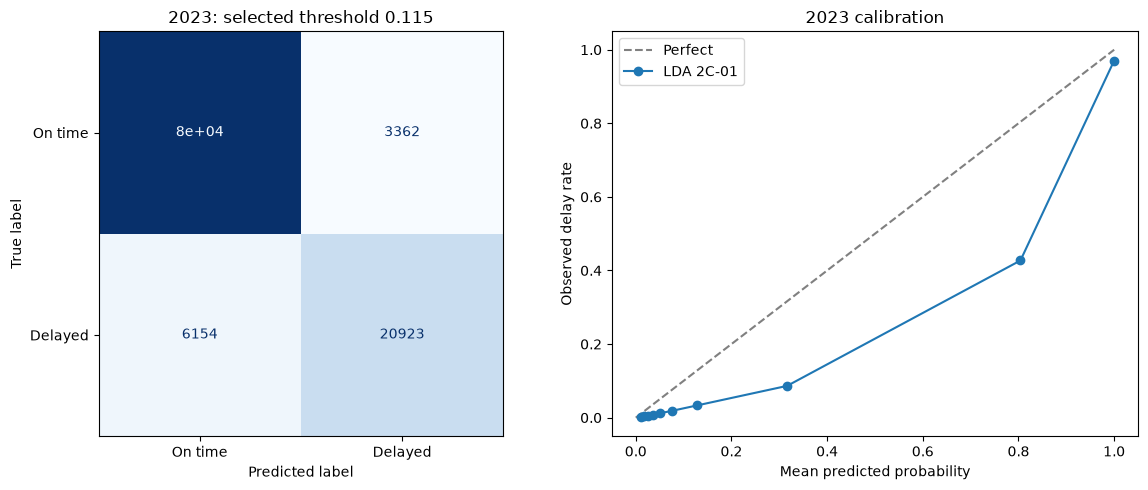

In [9]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"2023: selected threshold {selected_threshold:.3f}")
predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1].plot(predicted, observed, marker="o", label="LDA 2C-01")
axes[1].set(
    title="2023 calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
)
axes[1].legend()
fig.tight_layout()
plt.show()


## Inspect discriminant coefficients and publishable values

The coefficients describe the fitted linear discriminant after fold-local preprocessing. They show association with the classification boundary, not causal effects.


In [10]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["classifier"]
prepared_feature_names = preprocessor.get_feature_names_out()
coefficient_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "coefficient": classifier.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)
display(coefficient_table.head(25))

default = evaluation_results.loc["LDA 2C-01 (default)"]
selected = evaluation_results.loc["LDA 2C-01 (training-selected)"]
publishable_summary = pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "prepared predictors": len(prepared_feature_names),
    "selected solver": search.best_params_["classifier__solver"],
    "selected shrinkage": str(search.best_params_["classifier__shrinkage"]),
    "training CV AP": search.best_score_,
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
}, name="LDA 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()


,feature,coefficient,abs_coefficient
0,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-3.3842,3.3842
1,numeric__DepDelay,3.3605,3.3605
2,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,2.2248,2.2248
3,numeric__CRSElapsedTime,2.1007,2.1007
4,categorical__Origin_HNL,1.4402,1.4402
5,categorical__Reporting_Airline_HA,1.3737,1.3737
6,numeric__SCHEDULED_SPEED_PROXY,1.3578,1.3578
7,numeric__TaxiOut,1.0333,1.0333
8,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.9647,0.9647
9,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.9388,0.9388


,LDA 2C Experiment 01 Appendix F values
saved source fields,31
calculated model-side fields,1
prepared predictors,108
selected solver,lsqr
selected shrinkage,0.01
training CV AP,0.8889
validation prevalence,0.2463
validation AP,0.8979
validation ROC AUC,0.9394
validation Brier,0.0884


## Interpretation checklist

1. Does ordinary or shrinkage LDA win the 2019 temporal comparison?
2. Does LDA improve ranking, probability quality, F1, or MCC over Logistic Regression 2C-02?
3. Is the difference large enough to replace the preferred takeoff model?
4. Keep the existing feature dataset unchanged and keep 2024 untouched.
